Saved comparison plot to: c:\Users\rohan\Downloads\Exoskeleton_PD\exo_elbow\comparison_0-300k.png


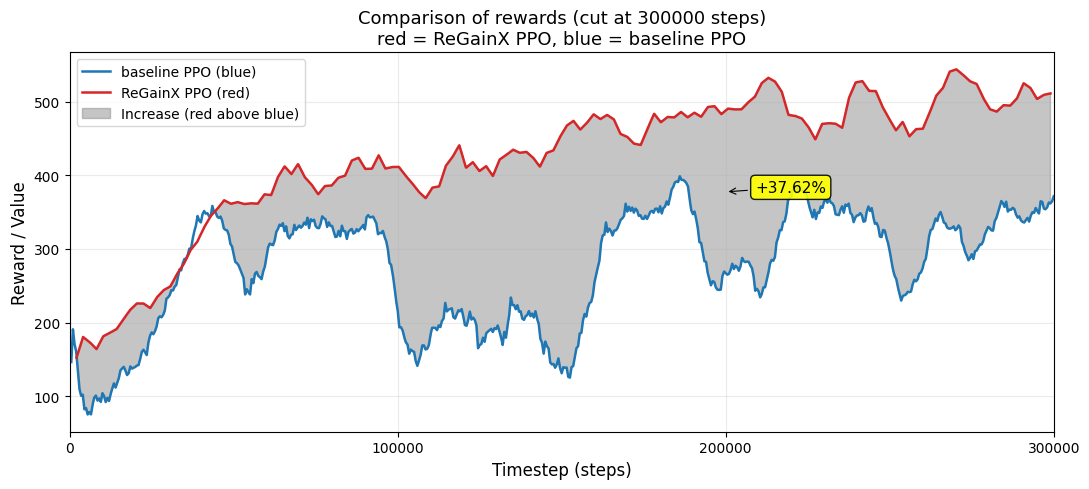

In [ ]:
# ...existing code...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- User paths: adjust if needed ---
path_red  = r"c:\Users\rohan\Downloads\csv.csv"       
path_blue = r"c:\Users\rohan\Downloads\csv (1).csv"   
x_cut = 300000                                        

df_red  = pd.read_csv(path_red)
df_blue = pd.read_csv(path_blue)

for df in (df_red, df_blue):
    df.columns = [c.strip() for c in df.columns]

df_red  = df_red[df_red['Step'] <= x_cut].sort_values('Step').reset_index(drop=True)
df_blue = df_blue[df_blue['Step'] <= x_cut].sort_values('Step').reset_index(drop=True)


x_common = np.linspace(0, x_cut, 3001) 

y_red  = np.interp(x_common,  df_red['Step'].to_numpy(),  df_red['Value'].to_numpy(), left=np.nan, right=np.nan)
y_blue = np.interp(x_common,  df_blue['Step'].to_numpy(), df_blue['Value'].to_numpy(), left=np.nan, right=np.nan)

valid_mask = ~np.isnan(y_red) & ~np.isnan(y_blue)

diff = y_red - y_blue
inc_mask = valid_mask & (diff > 0)

red_300k  = float(np.interp(x_cut, df_red['Step'],  df_red['Value']))
blue_300k = float(np.interp(x_cut, df_blue['Step'], df_blue['Value']))

if blue_300k != 0:
    pct_improv_300k = 100.0 * (red_300k - blue_300k) / blue_300k
    pct_text = f"{pct_improv_300k:+.2f}%"
else:
    pct_improv_300k = np.nan
    pct_text = "N/A"

plt.close('all')
fig, ax = plt.subplots(figsize=(11,5))

fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.plot(x_common, y_blue,  color='tab:blue',  lw=1.8, label='baseline PPO (blue)')
ax.plot(x_common, y_red,   color='tab:red',   lw=1.8, label='ReGainX PPO (red)')

ax.fill_between(x_common, y_blue, y_red, where=inc_mask, interpolate=True,
                color='grey', alpha=0.45, label='Increase (red above blue)')

ax.set_xlim(0, x_cut)
ax.set_xticks([0, 100000, 200000, 300000])
ax.set_xlabel('Timestep (steps)', fontsize=12)
ax.set_ylabel('Reward / Value', fontsize=12)
ax.set_title('Comparison of rewards (cut at 300000 steps)\nred = ReGainX PPO, blue = baseline PPO', fontsize=13)

ax.grid(alpha=0.25)

annot_x = 200000
idx = np.argmin(np.abs(x_common - annot_x))
if valid_mask[idx]:
    ypos = (y_red[idx] + y_blue[idx]) / 2.0
else:
    ymin, ymax = np.nanmin([y_blue[valid_mask], y_red[valid_mask]]), np.nanmax([y_blue[valid_mask], y_red[valid_mask]])
    ypos = ymin + 0.6 * (ymax - ymin)
ax.annotate(pct_text,
            xy=(annot_x, ypos),
            xytext=(annot_x + x_cut*0.03, ypos),
            fontsize=11,
            bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="black", alpha=0.9),
            arrowprops=dict(arrowstyle="->", color='black', lw=0.8))

ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()

out_png = r"c:\Users\rohan\Downloads\Exoskeleton_PD\exo_elbow\comparison_0-300k.png"
fig.savefig(out_png, dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
print(out_png)

plt.show()

Saved comparison plot to: C:\Users\rohan\Downloads\Exoskeleton_PD\exo_elbow\comparison_5algos_0-300k.png


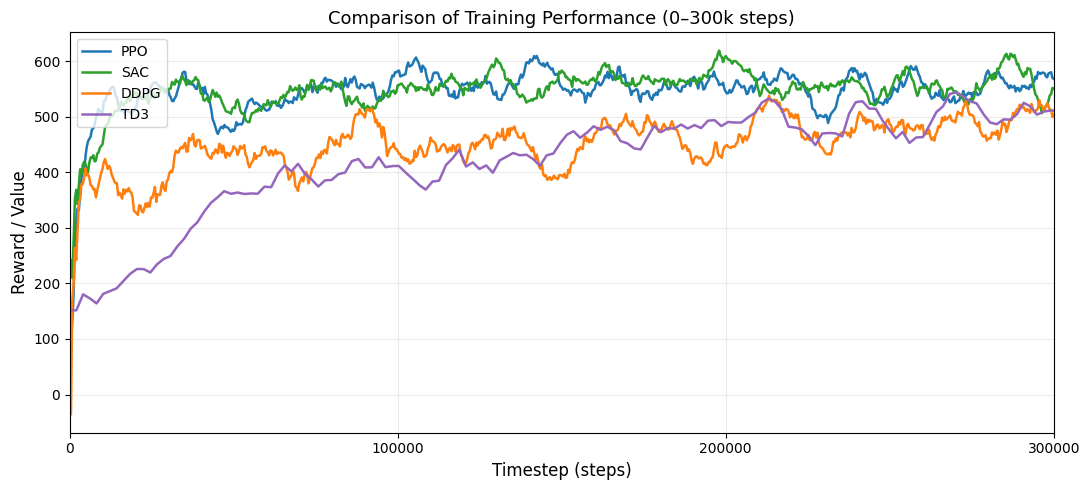

In [ ]:
#5 algos compare
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

paths = {
    "PPO":           r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_elbow\CompareTLogs\csv - TD3.csv",
    "SAC":           r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_elbow\CompareTLogs\csv - SAC.csv",
    "DDPG":          r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_elbow\CompareTLogs\csv - DDPG.csv",
    #"Baseline PPO":  r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_elbow\CompareTLogs\csv - baseline PPO.csv",
    "TD3":   r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_elbow\CompareTLogs\csv - PPO.csv"
}

x_cut = 300000  

dfs = {}
for label, path in paths.items():
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    if 'Step' not in df.columns or 'Value' not in df.columns:
        raise RuntimeError({path})

    df = df[df['Step'] <= x_cut].sort_values('Step').reset_index(drop=True)
    if df.empty:
        raise RuntimeError({path})

    dfs[label] = df

x_common = np.linspace(0, x_cut, 3001)

plt.close('all')
fig, ax = plt.subplots(figsize=(11,5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

colors = {
    "TD3": "tab:purple",
    "SAC": "tab:green",
    "DDPG": "tab:orange",
    "Baseline PPO": "tab:blue",
    "ReGainX PPO": "tab:red"
}

for label, df in dfs.items():
    y_interp = np.interp(x_common, df['Step'], df['Value'])
    ax.plot(x_common, y_interp, lw=1.8, label=label, color=colors.get(label, None))

ax.set_xlim(0, x_cut)
ax.set_xticks([0, 100000, 200000, 300000])
ax.set_xlabel('Timestep (steps)', fontsize=12)
ax.set_ylabel('Reward / Value', fontsize=12)
ax.set_title('Comparison of Training Performance (0–300k steps)', fontsize=13)
ax.grid(alpha=0.25)

ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()

out_png = r"C:\Users\rohan\Downloads\Exoskeleton_PD\exo_elbow\comparison_5algos_0-300k.png"
fig.savefig(out_png, dpi=200, bbox_inches='tight', facecolor=fig.get_facecolor())
print(out_png)

plt.show()


Saved latency comparison plot to: c:\Users\rohan\Downloads\Exoskeleton_PD\exo_elbow\data\..\plots\01_model_latency_comparison.png


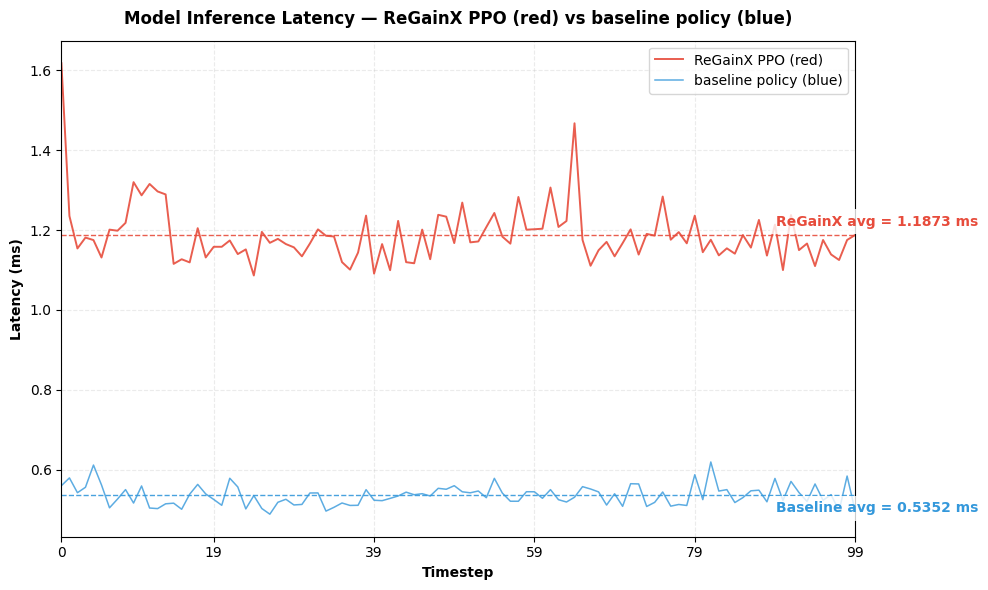

In [ ]:
#Latency Comp

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

p_og   = r"c:\Users\rohan\Downloads\Exoskeleton_PD\exo_elbow\data\latency_data_og.csv"
p_base = r"c:\Users\rohan\Downloads\Exoskeleton_PD\exo_elbow\data\latency_data_o.csv"

df_og   = pd.read_csv(p_og)
df_base = pd.read_csv(p_base)

agg_og   = df_og.groupby("step", as_index=False)["latency_ms"].mean().sort_values("step")
agg_base = df_base.groupby("step", as_index=False)["latency_ms"].mean().sort_values("step")

avg_og   = agg_og["latency_ms"].mean()
avg_base = agg_base["latency_ms"].mean()

plt.close("all")
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.plot(agg_og["step"],   agg_og["latency_ms"],   color="#e74c3c", linewidth=1.4, alpha=0.9, label="ReGainX PPO (red)")
ax.plot(agg_base["step"], agg_base["latency_ms"], color="#3498DB", linewidth=1.1, alpha=0.8, label="baseline policy (blue)")

ax.axhline(y=avg_og,   color="#e74c3c", linestyle="--", linewidth=1.0, alpha=0.9)
ax.axhline(y=avg_base, color="#3498DB", linestyle="--", linewidth=1.0, alpha=0.9)

xmax = max(agg_og["step"].max(), agg_base["step"].max())
x_annot = xmax * 0.90
ax.text(x_annot, avg_og * 1.02,   f"ReGainX avg = {avg_og:.4f} ms",   color="#e74c3c", fontsize=10, fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))
ax.text(x_annot, avg_base * 0.92, f"Baseline avg = {avg_base:.4f} ms", color="#3498DB", fontsize=10, fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))

ax.set_xlim(0, xmax)
ax.set_xlabel("Timestep", fontweight="bold")
ax.set_ylabel("Latency (ms)", fontweight="bold")
ax.set_title("Model Inference Latency — ReGainX PPO (red) vs baseline policy (blue)", fontweight="bold", pad=12)

ax.set_xticks(np.linspace(0, xmax, 6, dtype=int))

ax.grid(True, alpha=0.25, linestyle="--")
ax.legend(loc="upper right")
plt.tight_layout()

out_dir = os.path.join(os.path.dirname(p_base), "..", "plots")
os.makedirs(out_dir, exist_ok=True)
out_png = os.path.join(out_dir, "01_model_latency_comparison.png")
fig.savefig(out_png, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
print(out_png)

plt.show()